# Few-Shot Learning on Perch V2 Bioacoustic Embeddings

This notebook evaluates **few-shot learning** on dolphin whistle / background embeddings extracted with Google's Perch V2 model. The goal is to determine the minimum number of labeled samples needed to approach fully supervised performance.

Fully supervised training happens with max 805 samples per class, so our max shot value will be 805
### Strategy
- **Algorithms:** Logistic Regression · Decision Tree · Random Forest · SVM (RBF) · Nearest Centroid
- **Shot sizes:** 4, 8, 16, 32, 64, 128, 256, 512, 805 labeled examples *per class*
- **Repetitions:** 10 random seeds per shot size (to measure variance from sampling)
- **Test set:** All remaining data not used for training (≥126 samples per class even at 1024-shot)
- **Preprocessing:** L2-normalised embeddings, StandardScaler fitted on train split only
- **Baseline:** Fully supervised classifiers trained on 70/30 stratified split (loaded from CSV for comparison)

### Why these five?
| Model | Why it's included |
|---|---|
| Logistic Regression | Linear probe, strong regularisation, standard baseline for transfer learning |
| Decision Tree | Simple non-linear model, matches fully supervised setup |
| Random Forest | Ensemble of trees, robust to noise, matches fully supervised setup |
| SVM (RBF) | Maximises margin — top performer in fully supervised, tests if it holds with fewer samples |
| Nearest Centroid | Computes a class prototype (mean embedding) — zero fitting, mirrors Perch design intent |

### Key questions
1. How many labeled samples per class are needed to reach **90%** of fully supervised AUC?
2. At what point do **diminishing returns** set in — where doubling labels barely improves performance?
3. Which classifier is **most sample-efficient** — reaching high performance with the fewest labels?

## 0 · Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, time
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All imports OK.')

All imports OK.


## 1 · Load Data

In [2]:
BASE = '/data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA'

X = np.load(f'{BASE}/embeddings/X_embeddings.npy')   
y_raw = np.load(f'{BASE}/embeddings/y_labels.npy')   
meta = pd.read_csv(f'{BASE}/embeddings/metadata.csv')

# Encode labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_

print(f'Embeddings : {X.shape}')
print(f'Labels     : {y.shape}  → classes: {classes}')
print(f'Class distribution:')
for cls, idx in zip(classes, range(len(classes))):
    print(f'  [{idx}] {cls:20s}  n={np.sum(y == idx)}')

Embeddings : (1180, 1536)
Labels     : (1180,)  → classes: ['background' 'click+whistle' 'click_only' 'whistle_only']
Class distribution:
  [0] background            n=238
  [1] click+whistle         n=194
  [2] click_only            n=702
  [3] whistle_only          n=46


## 2 · Normalise Embeddings

L2-normalise so that distances in embedding space are meaningful for Nearest Centroid, and to put LR / SVM on equal footing. This is the standard practice for frozen Perch embeddings.

In [ ]:
norms = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = X / np.clip(norms, 1e-8, None)
print(f'Embeddings L2-normalised. Mean norm after: {np.linalg.norm(X_norm, axis=1).mean():.4f}')

Embeddings L2-normalised. Mean norm after: 1.0000


## 3 · Few-Shot Evaluation Framework

In [5]:
#@title Few-shot learning — 3-class (background / click_only / whistle_present)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from collections import defaultdict
import numpy as np
import time

# ── Classifier factory ───────────────────────────────────────────────────────
def make_classifiers():
    return {
        'Logistic Regression': LogisticRegression(
            C=1.0, max_iter=1000, solver='lbfgs',
            class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=RANDOM_SEED, n_jobs=-1
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', C=1.0, gamma='scale',
            probability=True, class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Nearest Centroid': NearestCentroid(metric='euclidean'),
    }

# ── Single few-shot trial (multiclass) ───────────────────────────────────────
def run_trial(X_all, y_all, n_shots, seed, classifiers):
    rng = np.random.RandomState(seed)
    classes = np.unique(y_all)

    train_idx, test_idx = [], []
    for cls in classes:
        cls_idx = np.where(y_all == cls)[0]
        n_train = min(n_shots, int(len(cls_idx) * 0.9))
        chosen = rng.choice(cls_idx, size=n_train, replace=False)
        train_idx.extend(chosen)
        test_idx.extend([i for i in cls_idx if i not in set(chosen)])

    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_all[train_idx])
    X_te = scaler.transform(X_all[test_idx])
    y_tr = y_all[train_idx]
    y_te = y_all[test_idx]

    results = {}
    for name, clf in classifiers.items():
        t0 = time.time()
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)

        if hasattr(clf, 'predict_proba'):
            y_proba = clf.predict_proba(X_te)
            try:
                auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='weighted')
            except ValueError:
                auc = float('nan')
        else:
            auc = float('nan')

        results[name] = {
            'accuracy': accuracy_score(y_te, y_pred),
            'macro_f1': f1_score(y_te, y_pred, average='macro', zero_division=0),
            'roc_auc': auc,
            'time_s': time.time() - t0,
        }
    return results

# ── Build 3-class labels ─────────────────────────────────────────────────────
label_remap = {
    'background': 'background',
    'click_only': 'click_only',
    'whistle_only': 'whistle_present',
    'click+whistle': 'whistle_present',
}
y_merged = np.array([label_remap[l] for l in y_raw])
le = LabelEncoder()
y = le.fit_transform(y_merged)
classes = le.classes_

print('Framework defined.')
print(f'\n3-class distribution:')
for i, cls in enumerate(classes):
    count = np.sum(y == i)
    print(f'  [{i}] {cls:20s}  n={count}  ratio={count/len(y):.3f}')

Framework defined.

3-class distribution:
  [0] background            n=238  ratio=0.202
  [1] click_only            n=702  ratio=0.595
  [2] whistle_present       n=240  ratio=0.203


In [6]:
min_class = min(np.sum(y == c) for c in range(len(classes)))
print(f'Min class size: {min_class}')

for s in [4, 8, 16, 32, 64, 128, 256, 512, 805]:
    test_per_class = min_class - s
    total_test = sum(np.sum(y == c) - s for c in range(len(classes)))
    print(f'  {s:>5d}-shot → {test_per_class:>5d} test samples in smallest class, {total_test:>5d} total test')

Min class size: 238
      4-shot →   234 test samples in smallest class,  1168 total test
      8-shot →   230 test samples in smallest class,  1156 total test
     16-shot →   222 test samples in smallest class,  1132 total test
     32-shot →   206 test samples in smallest class,  1084 total test
     64-shot →   174 test samples in smallest class,   988 total test
    128-shot →   110 test samples in smallest class,   796 total test
    256-shot →   -18 test samples in smallest class,   412 total test
    512-shot →  -274 test samples in smallest class,  -356 total test
    805-shot →  -567 test samples in smallest class, -1235 total test


## 4 · Run Experiments

10 random seeds × 8 shot sizes × 5 classifiers (~5 mins to run)

In [7]:
#@title Run few-shot experiments
min_class = min(np.sum(y == c) for c in range(len(classes)))
max_shots = int(min_class * 0.85)
SHOT_SIZES = [4, 8, 16, 32, 64, 128] 
N_TRIALS = 10
SEEDS = list(range(N_TRIALS))

print(f'Min class size: {min_class} | Max shots: {max_shots}')
print(f'Shot sizes: {SHOT_SIZES}')

records = defaultdict(lambda: defaultdict(list))
clf_names = list(make_classifiers().keys())

for n_shots in SHOT_SIZES:
    print(f'\n── {n_shots}-shot ({n_shots * len(classes)} total training samples) ──')
    for seed in SEEDS:
        clfs = make_classifiers()
        trial_results = run_trial(X_norm, y, n_shots, seed, clfs)
        for clf_name, metrics in trial_results.items():
            records[n_shots][clf_name].append(metrics)
    for clf_name in clf_names:
        f1s = [r['macro_f1'] for r in records[n_shots][clf_name]]
        print(f'  {clf_name:25s} F1={np.mean(f1s):.3f}±{np.std(f1s):.3f}')

print('\nFew-shot experiments complete.')

Min class size: 238 | Max shots: 202
Shot sizes: [4, 8, 16, 32, 64, 128]

── 4-shot (12 total training samples) ──
  Logistic Regression       F1=0.542±0.084
  Decision Tree             F1=0.434±0.047
  Random Forest             F1=0.530±0.065
  SVM (RBF)                 F1=0.521±0.077
  Nearest Centroid          F1=0.561±0.052

── 8-shot (24 total training samples) ──
  Logistic Regression       F1=0.576±0.059
  Decision Tree             F1=0.441±0.073
  Random Forest             F1=0.598±0.047
  SVM (RBF)                 F1=0.566±0.040
  Nearest Centroid          F1=0.602±0.032

── 16-shot (48 total training samples) ──
  Logistic Regression       F1=0.631±0.033
  Decision Tree             F1=0.492±0.049
  Random Forest             F1=0.633±0.030
  SVM (RBF)                 F1=0.604±0.039
  Nearest Centroid          F1=0.604±0.040

── 32-shot (96 total training samples) ──
  Logistic Regression       F1=0.663±0.026
  Decision Tree             F1=0.538±0.042
  Random Forest           

## 5 · Aggregate Results

In [8]:
# ── Save raw trial results ────────────────────────────────────────────────────
rows = []
for n_shots in SHOT_SIZES:
    for clf_name in clf_names:
        for trial_idx, metrics in enumerate(records[n_shots][clf_name]):
            rows.append({
                'n_shots': n_shots,
                'classifier': clf_name,
                'trial': trial_idx,
                'accuracy': metrics['accuracy'],
                'macro_f1': metrics['macro_f1'],
                'roc_auc': metrics['roc_auc'],
                'time_s': metrics['time_s'],
            })

fs_df = pd.DataFrame(rows)
fs_df.to_csv(f'{BASE}/few_shot/raw_trials.csv', index=False)
print(f'Raw trials saved → {BASE}/few_shot/raw_trials.csv  ({fs_df.shape})')

# ── Summary with mean ± std ───────────────────────────────────────────────────
summary_df = fs_df.groupby(['n_shots', 'classifier']).agg(
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    macro_f1_mean=('macro_f1', 'mean'),
    macro_f1_std=('macro_f1', 'std'),
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    time_mean=('time_s', 'mean'),
    time_std=('time_s', 'std'),
).reset_index()

summary_df.to_csv(f'{BASE}/few_shot/summary.csv', index=False)
print(f'Summary saved   → {BASE}/few_shot/summary.csv  ({summary_df.shape})')

Raw trials saved → /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/raw_trials.csv  ((300, 7))
Summary saved   → /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/summary.csv  ((30, 10))


## 6 · Visualisations

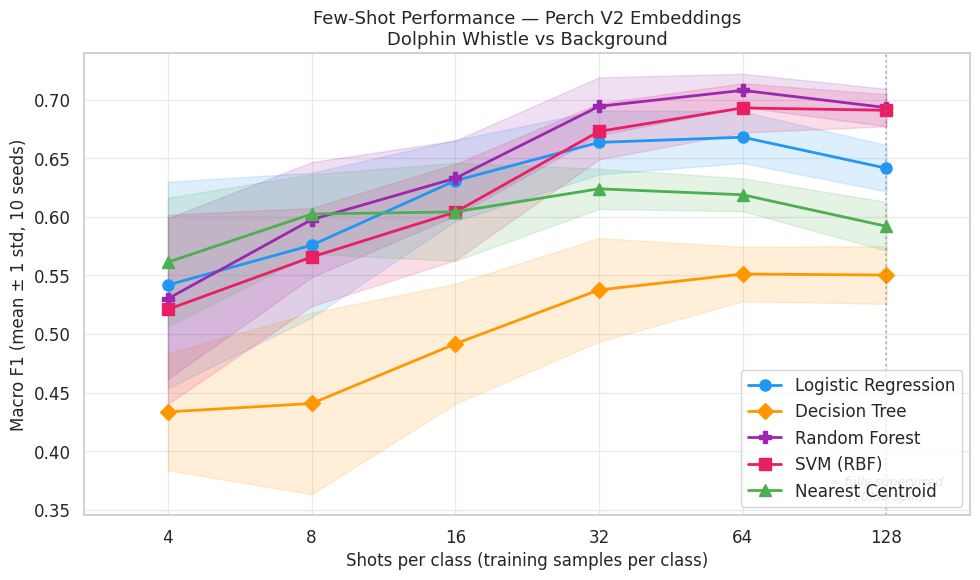

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/f1_curve.png


In [9]:
# ── 6.1  Macro F1 vs Shot Size (mean ± std ribbon) + fully supervised ref ────
CLF_COLORS = {
    'Logistic Regression': '#2196F3',
    'Decision Tree'      : '#FF9800',
    'Random Forest'      : '#9C27B0',
    'SVM (RBF)'          : '#E91E63',
    'Nearest Centroid'   : '#4CAF50',
}


CLF_MARKERS = {
    'Logistic Regression': 'o',
    'Decision Tree'      : 'D',
    'Random Forest'      : 'P',
    'SVM (RBF)'          : 's',
    'Nearest Centroid'   : '^',
}

fig, ax = plt.subplots(figsize=(10, 6))

# Few-shot curves
for clf_name in clf_names:
    sub = summary_df[summary_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['macro_f1_mean'], marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    (sub['macro_f1_mean'] - sub['macro_f1_std']).values,
                    (sub['macro_f1_mean'] + sub['macro_f1_std']).values,
                    alpha=0.15, color=color)

# Mark the last shot size as fully-supervised equivalent
ax.axvline(SHOT_SIZES[-1], color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(SHOT_SIZES[-1], ax.get_ylim()[0] + 0.01, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')

ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel('Macro F1 (mean ± 1 std, 10 seeds)', fontsize=12)
ax.set_title('Few-Shot Performance — Perch V2 Embeddings\nDolphin Whistle vs Background', fontsize=13)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(SHOT_SIZES[0] / 1.5, SHOT_SIZES[-1] * 1.5)
ax.legend(frameon=True, loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/f1_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/f1_curve.png')

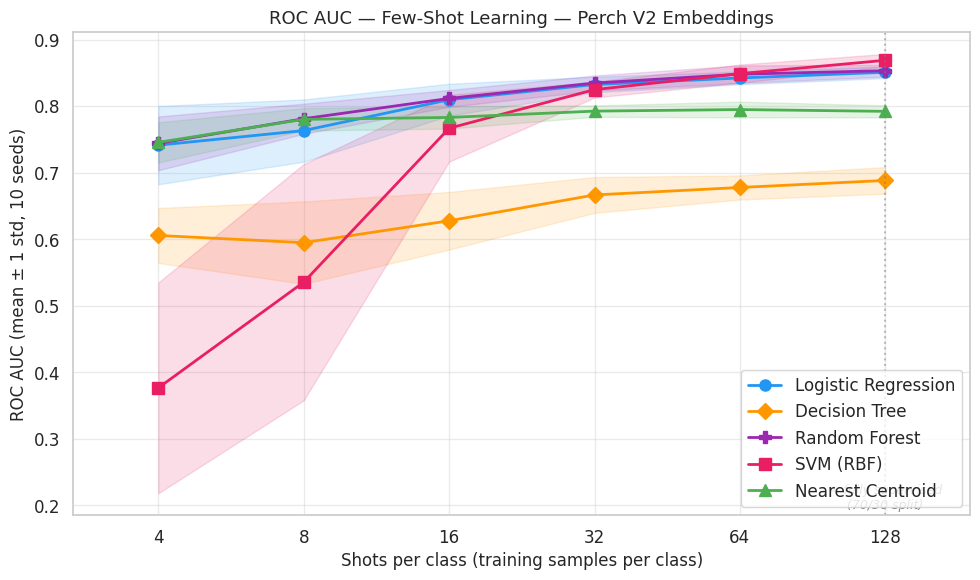

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/auc_curve.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

for clf_name in clf_names:
    sub = summary_df[summary_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['roc_auc_mean'], marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    np.clip((sub['roc_auc_mean'] - sub['roc_auc_std']).values, 0, 1),
                    np.clip((sub['roc_auc_mean'] + sub['roc_auc_std']).values, 0, 1),
                    alpha=0.15, color=color)

ax.axvline(SHOT_SIZES[-1], color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(SHOT_SIZES[-1], ax.get_ylim()[0] + 0.005, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')

ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel('ROC AUC (mean ± 1 std, 10 seeds)', fontsize=12)
ax.set_title('ROC AUC — Few-Shot Learning — Perch V2 Embeddings', fontsize=13)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(SHOT_SIZES[0] / 1.5, SHOT_SIZES[-1] * 1.5)
ax.legend(frameon=True, loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/auc_curve.png')

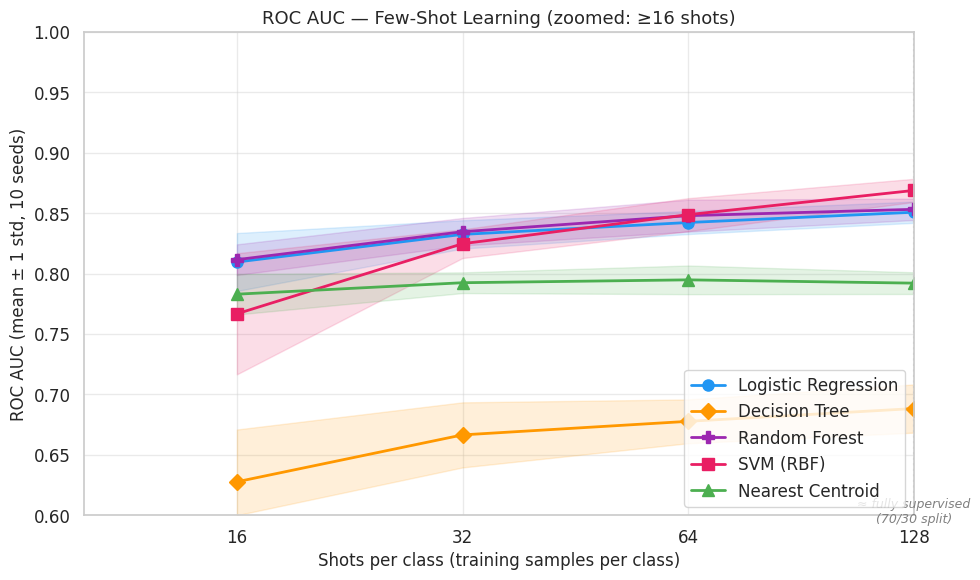

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/auc_curve_zoomed.png


In [11]:
# ── 6.2b  ROC AUC vs Shot Size — Zoomed (16+ shots, AUC 0.6–1.0) ─────────────
fig, ax = plt.subplots(figsize=(10, 6))

shot_sizes_zoom = [s for s in SHOT_SIZES if s >= 16]

for clf_name in clf_names:
    sub = summary_df[(summary_df.classifier == clf_name) & (summary_df.n_shots >= 16)].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['roc_auc_mean'], marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    np.clip((sub['roc_auc_mean'] - sub['roc_auc_std']).values, 0.6, 1),
                    np.clip((sub['roc_auc_mean'] + sub['roc_auc_std']).values, 0.6, 1),
                    alpha=0.15, color=color)



ax.axvline(SHOT_SIZES[-1], color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(SHOT_SIZES[-1], ax.get_ylim()[0] + 0.005, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')


ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel('ROC AUC (mean ± 1 std, 10 seeds)', fontsize=12)
ax.set_title('ROC AUC — Few-Shot Learning (zoomed: ≥16 shots)', fontsize=13)
ax.set_xticks(shot_sizes_zoom)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(shot_sizes_zoom[0] / 1.6, shot_sizes_zoom[-2] * 2)
ax.set_ylim(0.6, 1.0)
ax.legend(frameon=True, loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/auc_curve_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/auc_curve_zoomed.png')

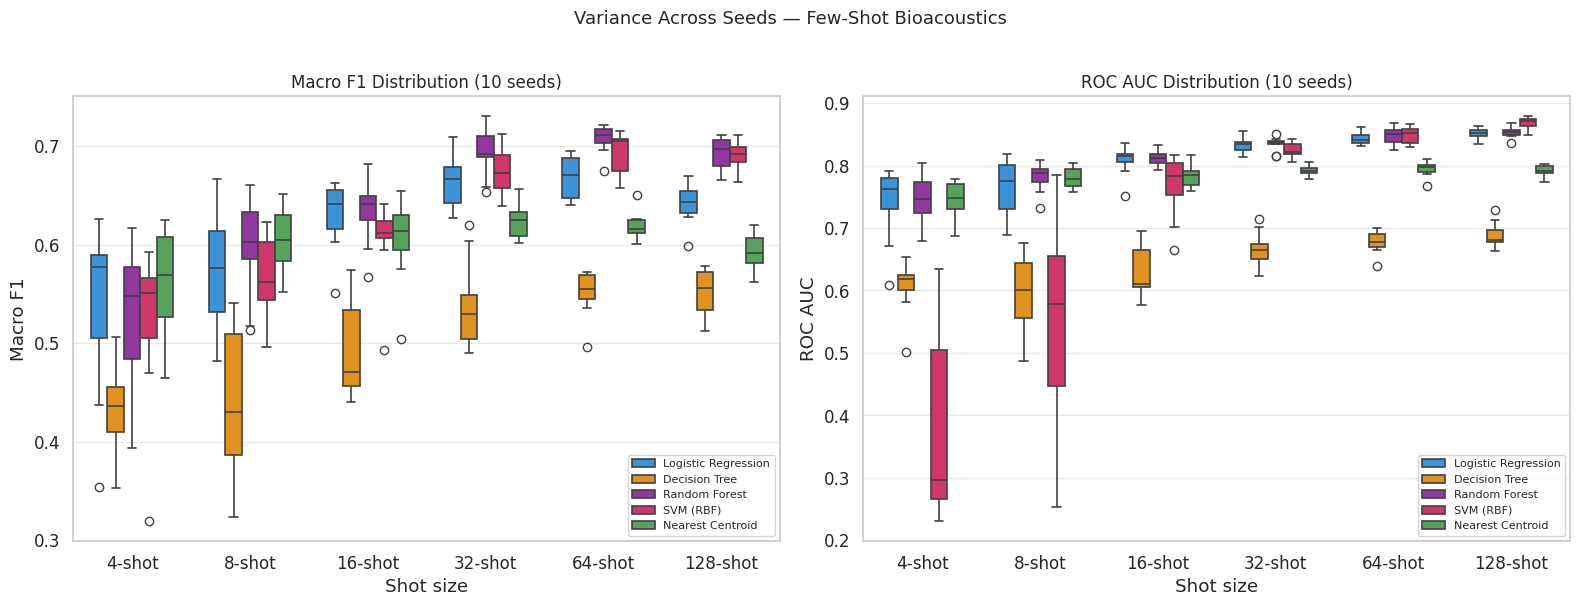

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/boxplots.png


In [12]:
# ── 6.3  Box plots of F1 distribution across seeds (all shots, all clfs) ─────
long_rows = []
for n_shots in SHOT_SIZES:
    for clf_name in clf_names:
        for trial in records[n_shots][clf_name]:
            long_rows.append({
                'n_shots'   : f'{n_shots}-shot',
                'classifier': clf_name,
                'macro_f1'  : trial['macro_f1'],
                'roc_auc'   : trial['roc_auc'],
            })
long_df = pd.DataFrame(long_rows)

# Ensure shot order is correct
shot_order = [f'{s}-shot' for s in SHOT_SIZES]
long_df['n_shots'] = pd.Categorical(long_df['n_shots'], categories=shot_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(
    axes,
    ['macro_f1', 'roc_auc'],
    ['Macro F1', 'ROC AUC']
):
    sns.boxplot(
        data=long_df, x='n_shots', y=metric, hue='classifier',
        palette=CLF_COLORS, ax=ax, linewidth=1.2, width=0.7
    )
    ax.set_title(f'{title} Distribution (10 seeds)', fontsize=12)
    ax.set_xlabel('Shot size')
    ax.set_ylabel(title)
    ax.legend(title='', fontsize=8, loc='lower right')
    ax.grid(True, axis='y', alpha=0.4)

plt.suptitle('Variance Across Seeds — Few-Shot Bioacoustics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/boxplots.png')

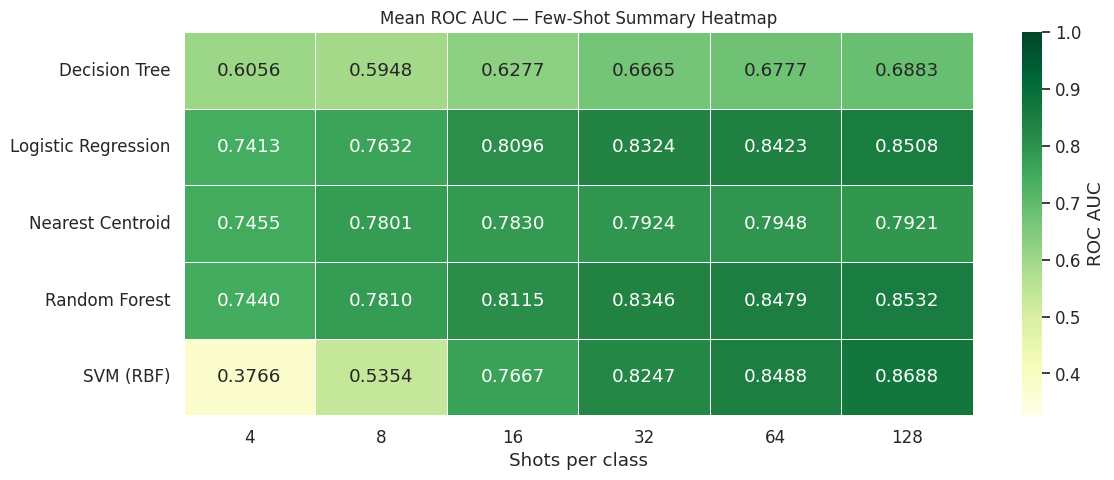

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/heatmap_auc.png


In [13]:
# ── 6.4  Heatmap: mean ROC AUC  (clf × shot size) ───────────────────────────
heatmap_data = summary_df.pivot(
    index='classifier', columns='n_shots', values='roc_auc_mean'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f', cmap='YlGn',
    vmin=heatmap_data.values.min() - 0.05, vmax=1.0, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'ROC AUC'}
)
ax.set_title('Mean ROC AUC — Few-Shot Summary Heatmap', fontsize=12)
ax.set_xlabel('Shots per class')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/heatmap_auc.png')

## 7 · Detailed Report at Best Shot Size Reported to Shot Size

Full classification report + confusion matrix for 16-shot (best seed)


─── Logistic Regression (16-shot, seed 0) ───
                 precision    recall  f1-score   support

     background       0.56      0.82      0.67       222
     click_only       0.82      0.67      0.74       686
whistle_present       0.54      0.60      0.57       224

       accuracy                           0.69      1132
      macro avg       0.64      0.70      0.66      1132
   weighted avg       0.72      0.69      0.69      1132


─── Decision Tree (16-shot, seed 0) ───
                 precision    recall  f1-score   support

     background       0.51      0.66      0.57       222
     click_only       0.76      0.70      0.73       686
whistle_present       0.43      0.41      0.42       224

       accuracy                           0.63      1132
      macro avg       0.57      0.59      0.57      1132
   weighted avg       0.65      0.63      0.64      1132


─── Random Forest (16-shot, seed 0) ───
                 precision    recall  f1-score   support

     back

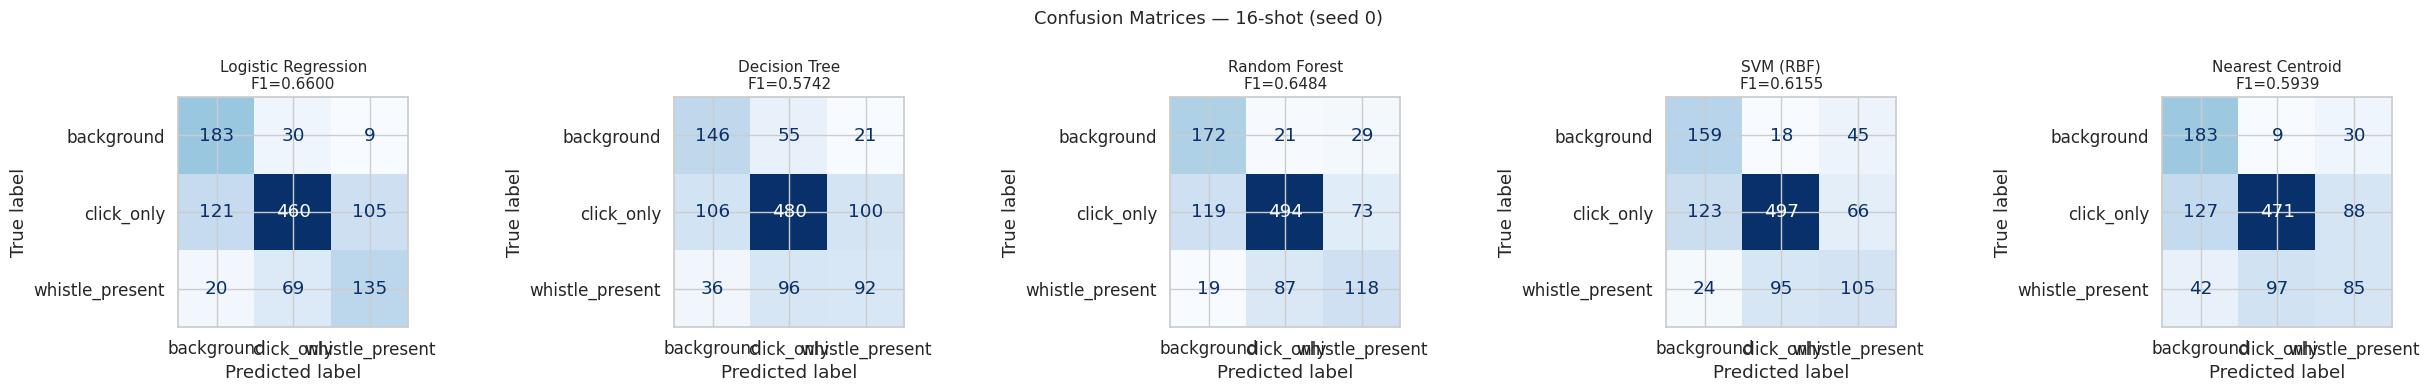

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/confusion.png


In [14]:
BEST_SHOTS = 16
REPORT_SEED = 0

clfs = make_classifiers()
trial_results = run_trial(X_norm, y, BEST_SHOTS, REPORT_SEED, clfs)

# Re-run to get predictions (run_trial only returns metrics now)
rng = np.random.RandomState(REPORT_SEED)
train_idx, test_idx = [], []
for cls in range(len(classes)):
    cls_idx = np.where(y == cls)[0]
    chosen = rng.choice(cls_idx, size=BEST_SHOTS, replace=False)
    train_idx.extend(chosen)
    test_idx.extend([i for i in cls_idx if i not in set(chosen)])

scaler_rep = StandardScaler()
X_tr_rep = scaler_rep.fit_transform(X_norm[train_idx])
X_te_rep = scaler_rep.transform(X_norm[test_idx])
y_tr_rep = y[train_idx]
y_te_rep = y[test_idx]

# Get predictions from each classifier
y_preds = {}
for name, clf in clfs.items():
    clf.fit(X_tr_rep, y_tr_rep)
    y_preds[name] = clf.predict(X_te_rep)

# Plot confusion matrices
n_clfs = len(clfs)
fig, axes = plt.subplots(1, n_clfs, figsize=(5 * n_clfs, 4))

for ax, clf_name in zip(axes, clfs.keys()):
    cm = confusion_matrix(y_te_rep, y_preds[clf_name])
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1 = trial_results[clf_name]['macro_f1']
    ax.set_title(f'{clf_name}\nF1={f1:.4f}', fontsize=11)

    print(f'\n─── {clf_name} ({BEST_SHOTS}-shot, seed {REPORT_SEED}) ───')
    print(classification_report(y_te_rep, y_preds[clf_name], target_names=classes))

plt.suptitle(f'Confusion Matrices — {BEST_SHOTS}-shot (seed {REPORT_SEED})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/confusion.png')

## 8 · Efficiency — F1 Gain per Additional Sample

=== ROC AUC Gain per Shot Step ===
  Decision Tree
    4→8 shots: -0.0108 AUC
    8→16 shots: +0.0329 AUC
    16→32 shots: +0.0388 AUC
    32→64 shots: +0.0112 AUC
    64→128 shots: +0.0106 AUC
  Logistic Regression
    4→8 shots: +0.0219 AUC
    8→16 shots: +0.0464 AUC
    16→32 shots: +0.0229 AUC
    32→64 shots: +0.0098 AUC
    64→128 shots: +0.0085 AUC
  Nearest Centroid
    4→8 shots: +0.0346 AUC
    8→16 shots: +0.0029 AUC
    16→32 shots: +0.0095 AUC
    32→64 shots: +0.0024 AUC
    64→128 shots: -0.0027 AUC
  Random Forest
    4→8 shots: +0.0370 AUC
    8→16 shots: +0.0305 AUC
    16→32 shots: +0.0231 AUC
    32→64 shots: +0.0133 AUC
    64→128 shots: +0.0053 AUC
  SVM (RBF)
    4→8 shots: +0.1589 AUC
    8→16 shots: +0.2313 AUC
    16→32 shots: +0.0580 AUC
    32→64 shots: +0.0240 AUC
    64→128 shots: +0.0201 AUC


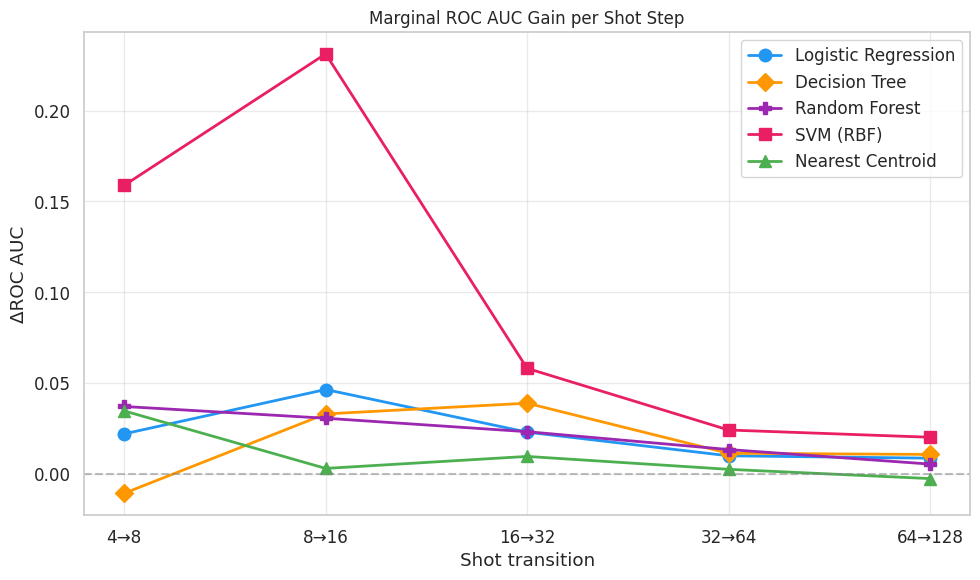

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/auc_gain.png


In [15]:
# ── 6.5  Marginal AUC gain per shot step ─────────────────────────────────────
auc_means = summary_df.pivot(
    index='classifier', columns='n_shots', values='roc_auc_mean'
)

print('=== ROC AUC Gain per Shot Step ===')
shot_pairs = list(zip(SHOT_SIZES, SHOT_SIZES[1:]))
for clf in auc_means.index:
    print(f'  {clf}')
    for s1, s2 in shot_pairs:
        gain = auc_means.loc[clf, s2] - auc_means.loc[clf, s1]
        print(f'    {s1}→{s2} shots: {gain:+.4f} AUC')

# Plot efficiency curves
fig, ax = plt.subplots(figsize=(10, 6))
for clf_name in clf_names:
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')
    gains = [
        auc_means.loc[clf_name, s2] - auc_means.loc[clf_name, s1]
        for s1, s2 in shot_pairs
    ]
    x_labels = [f'{s1}→{s2}' for s1, s2 in shot_pairs]
    ax.plot(x_labels, gains, marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=9)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Marginal ROC AUC Gain per Shot Step', fontsize=12)
ax.set_xlabel('Shot transition')
ax.set_ylabel('ΔROC AUC')
ax.legend(frameon=True, loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/auc_gain.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/auc_gain.png')

## 9 · Timing Comparison

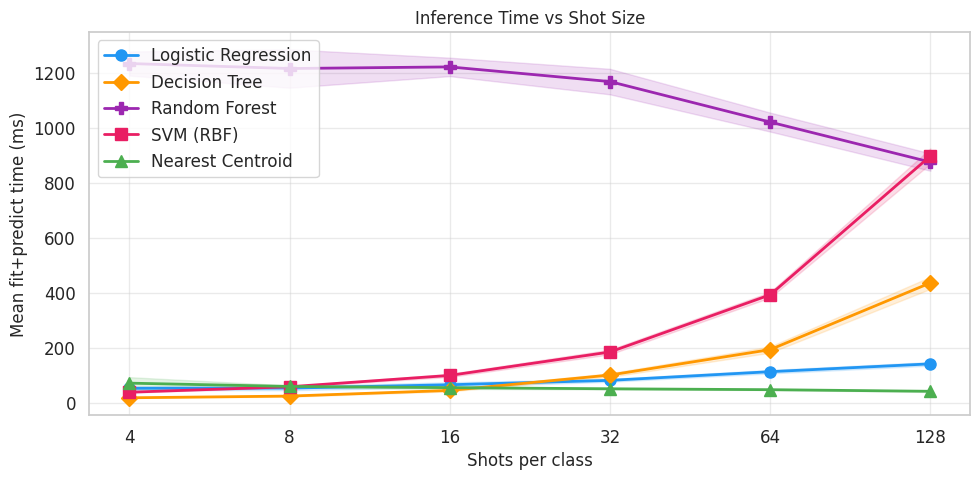

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/timing.png


In [16]:
# ── 6.6  Inference time vs shot size ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for clf_name in clf_names:
    sub = summary_df[summary_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['time_mean'] * 1000, marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    ((sub['time_mean'] - sub['time_std']) * 1000).values,
                    ((sub['time_mean'] + sub['time_std']) * 1000).values,
                    alpha=0.15, color=color)

ax.set_xlabel('Shots per class', fontsize=12)
ax.set_ylabel('Mean fit+predict time (ms)', fontsize=12)
ax.set_title('Inference Time vs Shot Size', fontsize=12)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.legend(frameon=True, loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/timing.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/timing.png')

## 10 · Conclusions

Compare few-shot best vs full-dataset results.

PREDICTIVE POWER RETENTION — % of 128-shot ROC AUC (≈ fully supervised)
n_shots               4     8     16     32     64     128
classifier                                                
Decision Tree        88.0  86.4  91.2   96.8   98.5  100.0
Logistic Regression  87.1  89.7  95.2   97.8   99.0  100.0
Nearest Centroid     94.1  98.5  98.8  100.0  100.0  100.0
Random Forest        87.2  91.5  95.1   97.8   99.4  100.0
SVM (RBF)            43.3  61.6  88.2   94.9   97.7  100.0


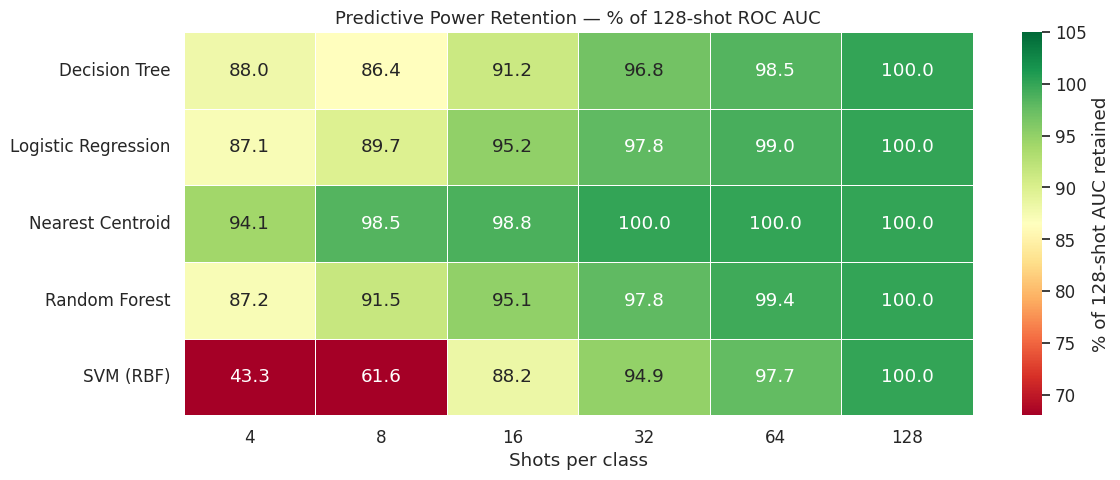

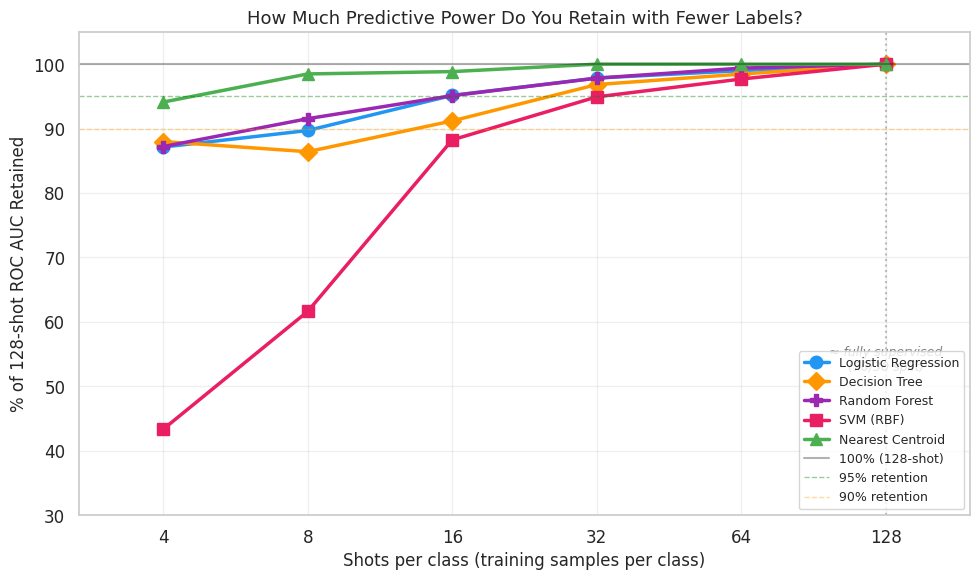

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/retention_curves_auc.png

── Key Takeaways ──
  Logistic Regression        90% retention at: 16-shot  |  95% retention at: 16-shot
  Decision Tree              90% retention at: 16-shot  |  95% retention at: 32-shot
  Random Forest              90% retention at: 8-shot  |  95% retention at: 16-shot
  SVM (RBF)                  90% retention at: 32-shot  |  95% retention at: 64-shot
  Nearest Centroid           90% retention at: 4-shot  |  95% retention at: 8-shot

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/retention_heatmap_auc.png
Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/retention_curves_auc.png


In [18]:
#@title Predictive power retention — % of max ROC AUC retained per shot size

# ── Compute retention using largest shot size as reference ─────────────────────
max_shot = SHOT_SIZES[-1]

retention_rows = []
for clf_name in clf_names:
    # Use the largest shot size as the "full" reference
    ref_row = summary_df[(summary_df.classifier == clf_name) & (summary_df.n_shots == max_shot)]
    full_auc = ref_row['roc_auc_mean'].values[0]
    
    for n_shots in SHOT_SIZES:
        row = summary_df[(summary_df.classifier == clf_name) & (summary_df.n_shots == n_shots)]
        few_auc = row['roc_auc_mean'].values[0]
        few_std = row['roc_auc_std'].values[0]
        retention = (few_auc / full_auc) * 100
        retention_std = (few_std / full_auc) * 100
        retention_rows.append({
            'classifier': clf_name,
            'n_shots': n_shots,
            'few_auc': few_auc,
            'full_auc': full_auc,
            'retention_pct': retention,
            'retention_std': retention_std,
        })

ret_df = pd.DataFrame(retention_rows)
ret_df['retention_pct'] = ret_df['retention_pct'].clip(upper=100)

# ── Print table ───────────────────────────────────────────────────────────────
print('=' * 100)
print(f'PREDICTIVE POWER RETENTION — % of {max_shot}-shot ROC AUC (≈ fully supervised)')
print('=' * 100)
pivot = ret_df.pivot(index='classifier', columns='n_shots', values='retention_pct')
print(pivot.round(1).to_string())

# ── Plot 1: Retention heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
heatmap_data = ret_df.pivot(index='classifier', columns='n_shots', values='retention_pct')

sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=68, vmax=105, ax=ax, linewidths=0.5,
    cbar_kws={'label': f'% of {max_shot}-shot AUC retained'}
)
ax.set_title(f'Predictive Power Retention — % of {max_shot}-shot ROC AUC', fontsize=13)
ax.set_xlabel('Shots per class')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/retention_heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Retention curves with threshold lines ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for clf_name in clf_names:
    sub = ret_df[ret_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['retention_pct'], marker=marker,
            color=color, label=clf_name, linewidth=2.5, markersize=9)

ax.axhline(100, color='black', linestyle='-', alpha=0.3, linewidth=1.5, label=f'100% ({max_shot}-shot)')
ax.axhline(95, color='green', linestyle='--', alpha=0.4, linewidth=1, label='95% retention')
ax.axhline(90, color='orange', linestyle='--', alpha=0.4, linewidth=1, label='90% retention')

ax.axvline(max_shot, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(max_shot, 52, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')

ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel(f'% of {max_shot}-shot ROC AUC Retained', fontsize=12)
ax.set_title('How Much Predictive Power Do You Retain with Fewer Labels?', fontsize=13)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(SHOT_SIZES[0] / 1.5, SHOT_SIZES[-1] * 1.5)
ax.set_ylim(30, 105)
ax.legend(frameon=True, loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/retention_curves_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/retention_curves_auc.png')

# ── Key takeaways ─────────────────────────────────────────────────────────────
print('\n── Key Takeaways ──')
for clf_name in clf_names:
    sub = ret_df[ret_df.classifier == clf_name]
    above_90 = sub[sub.retention_pct >= 90].n_shots.min()
    above_95 = sub[sub.retention_pct >= 95].n_shots.min()
    print(f'  {clf_name:<25s}  90% retention at: {above_90 if pd.notna(above_90) else f">{max_shot}"}-shot'
          f'  |  95% retention at: {above_95 if pd.notna(above_95) else f">{max_shot}"}-shot')

print(f'\nSaved: {BASE}/few_shot/retention_heatmap_auc.png')
print(f'Saved: {BASE}/few_shot/retention_curves_auc.png')

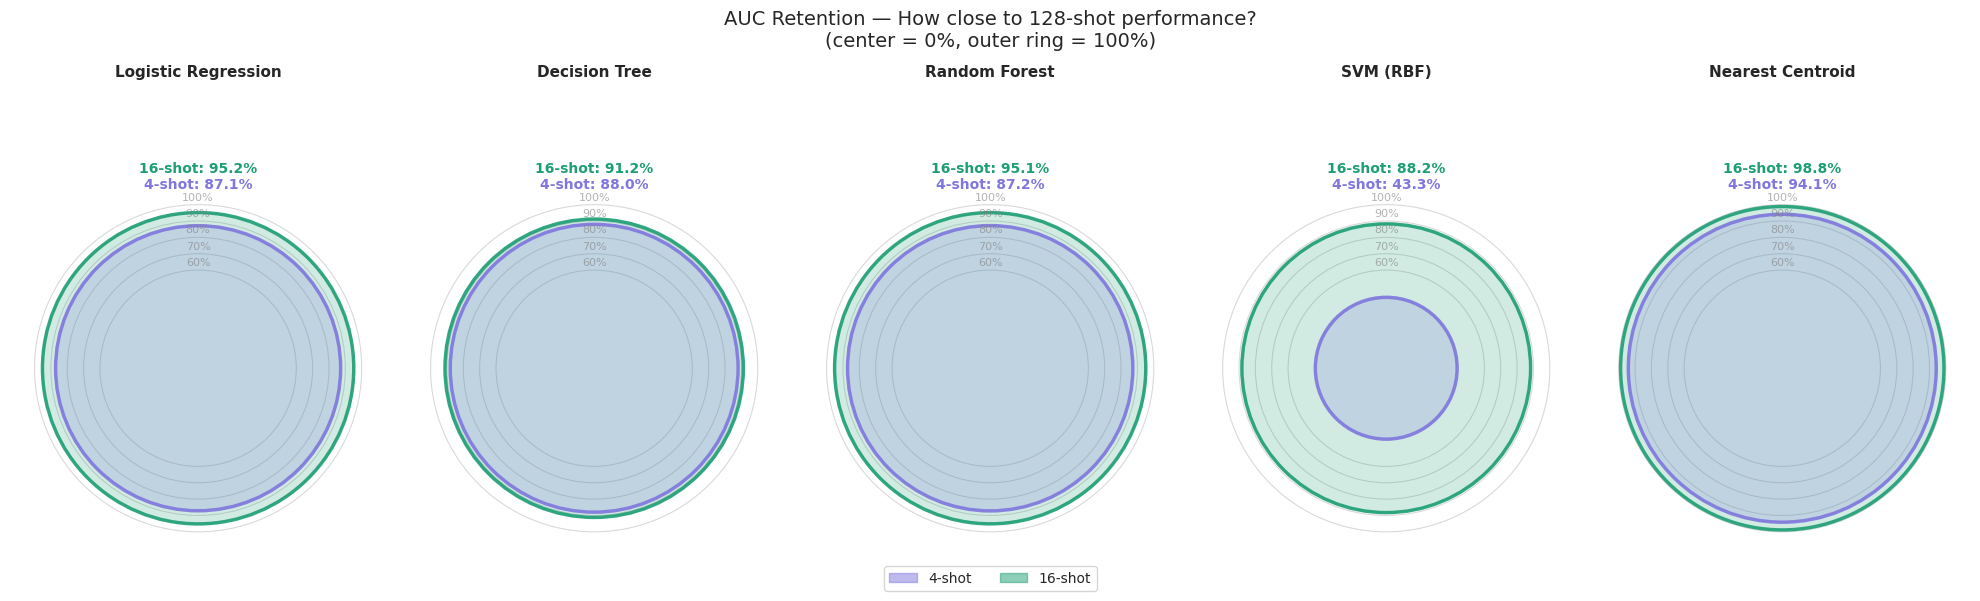

Saved: /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/few_shot/retention_bullseye.png


In [19]:
#@title Bullseye retention chart — AUC retention at 4, 16, 256 shots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Shot sizes to compare
radar_shots = [4, 16]
shot_colors = ['#7F77DD', '#1D9E75']
shot_labels = ['4-shot', '16-shot']

max_shot = SHOT_SIZES[-1]

# Compute retention using max shot as reference
retention = {}
for s in radar_shots:
    retention[s] = []
    for clf in clf_names:
        ref_auc = summary_df[(summary_df.classifier == clf) & (summary_df.n_shots == max_shot)]['roc_auc_mean'].values[0]
        few_auc = summary_df[(summary_df.classifier == clf) & (summary_df.n_shots == s)]['roc_auc_mean'].values[0]
        retention[s].append(min((few_auc / ref_auc) * 100, 100))

n_clfs = len(clf_names)
fig, axes = plt.subplots(1, n_clfs, figsize=(4 * n_clfs, 5.5))

for ax, clf_idx, clf_name in zip(axes, range(n_clfs), clf_names):
    # Draw target rings
    for ring_pct in [60, 70, 80, 90, 100]:
        circle = plt.Circle((0, 0), ring_pct, fill=False, color='gray',
                            linewidth=0.8, alpha=0.3, linestyle='-')
        ax.add_patch(circle)
        ax.text(0, ring_pct + 1.5, f'{ring_pct}%', ha='center', va='bottom',
                fontsize=8, color='gray', alpha=0.6)

    # Draw filled arcs for each shot size (largest first so smaller ones are on top)
    for s, color, label in reversed(list(zip(radar_shots, shot_colors, shot_labels))):
        val = retention[s][clf_idx]
        circle_fill = plt.Circle((0, 0), val, color=color, alpha=0.2)
        circle_edge = plt.Circle((0, 0), val, fill=False, color=color, linewidth=2.5, alpha=0.9)
        ax.add_patch(circle_fill)
        ax.add_patch(circle_edge)

    # Value labels stacked at top, outside the circles
    y_start = 108
    for s, color, label in zip(radar_shots, shot_colors, shot_labels):
        val = retention[s][clf_idx]
        ax.text(0, y_start, f'{label}: {val:.1f}%', ha='center', va='bottom',
                fontsize=10, color=color, fontweight='bold')
        y_start += 10

    ax.set_xlim(-115, 115)
    ax.set_ylim(-115, 140)
    ax.set_aspect('equal')
    ax.set_title(clf_name, fontsize=11, fontweight='bold', pad=45)
    ax.axis('off')

# Shared legend
legend_patches = [mpatches.Patch(color=c, alpha=0.5, label=l)
                  for c, l in zip(shot_colors, shot_labels)]
fig.legend(handles=legend_patches, loc='lower center', ncol=len(legend_patches),
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f'AUC Retention — How close to {max_shot}-shot performance?\n(center = 0%, outer ring = 100%)',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/retention_bullseye.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/retention_bullseye.png')